In [173]:
import pandas as pd
from pathlib import Path
import yaml
import matplotlib.pyplot as plt

In [174]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

# Analyzing data from Games endpoint

In [175]:
clean_games_fp = Path(config['games_folder'] + config['games_clean_fp'])

games_df = pd.read_json(clean_games_fp, orient='records')
games_df['updated_at'] = pd.to_datetime(games_df['updated_at'], errors='coerce')
games_df['first_release_date'] = pd.to_datetime(games_df['first_release_date'], errors='coerce')

print(f"Total number of games: {len(games_df)}")
games_df.head()

Total number of games: 19038


,name,rating,updated_at,first_release_date,id,game_modes_Battle Royale,game_modes_Co-operative,game_modes_Massively Multiplayer Online (MMO),game_modes_Multiplayer,game_modes_Single player,...,platforms_WonderSwan Color,platforms_Xbox,platforms_Xbox 360,platforms_Xbox One,platforms_Xbox Series X|S,platforms_ZX Spectrum,platforms_Zeebo,platforms_e-Reader / Card-e Reader,platforms_iOS,platforms_visionOS
0,Warframe,74.773808,2026-05-01 15:49:54,2013-03-25,2903,0,1,0,1,1,...,0,0,0,1,1,0,0,0,1,0
1,The Elder Scrolls Online,71.794992,2026-05-01 15:49:43,2014-04-04,1081,0,1,1,1,1,...,0,0,0,1,1,0,0,0,0,0
2,Call of Duty: Warzone,66.793295,2026-05-01 15:49:41,2022-11-16,217815,1,1,0,1,1,...,0,0,0,1,1,0,0,0,0,0
3,Fallout 76,60.899389,2026-05-01 15:49:41,2018-11-14,103020,0,1,1,1,0,...,0,0,0,1,1,0,0,0,0,0
4,LEGO Star Wars: The Skywalker Saga,80.479426,2026-05-01 15:49:18,2022-04-05,119305,0,1,0,1,1,...,0,0,0,1,1,0,0,0,0,0


### How many games of each mode

<BarContainer object of 6 artists>

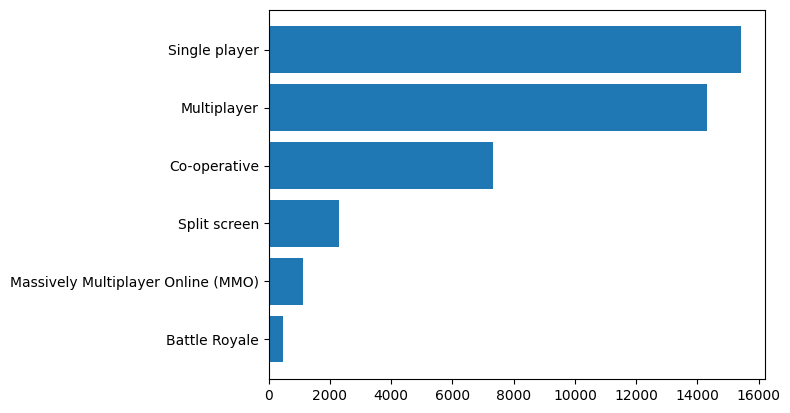

In [176]:
mode_columns = [column for column in games_df.columns if "game_modes" in column]

game_modes_df = games_df[mode_columns]

game_modes_df.columns = [column[len('game_modes_'):] for column in game_modes_df.columns]

game_mode_amounts = game_modes_df.sum().sort_values(ascending = True)

plt.barh(game_mode_amounts.index, game_mode_amounts.values)

### How many games of each genre

<BarContainer object of 23 artists>

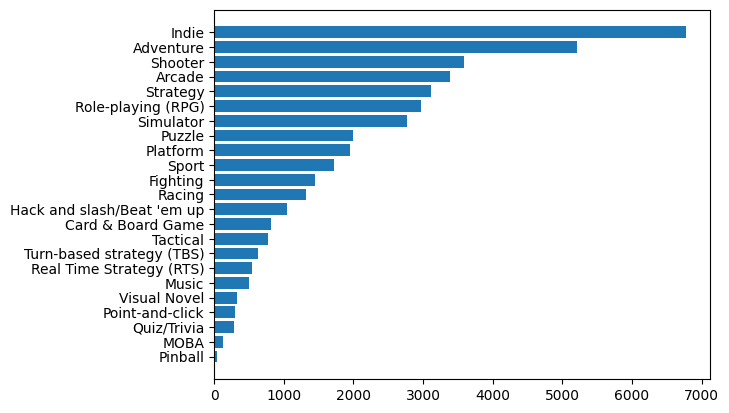

In [177]:
genre_columns = [column for column in games_df.columns if "genres" in column]

genres_df = games_df[genre_columns]

genres_df.columns = [column[len('genres_'):] for column in genres_df.columns]

genres_amounts = genres_df.sum().sort_values(ascending = True)

plt.barh(genres_amounts.index, genres_amounts.values)

### How many games from each platform

<BarContainer object of 10 artists>

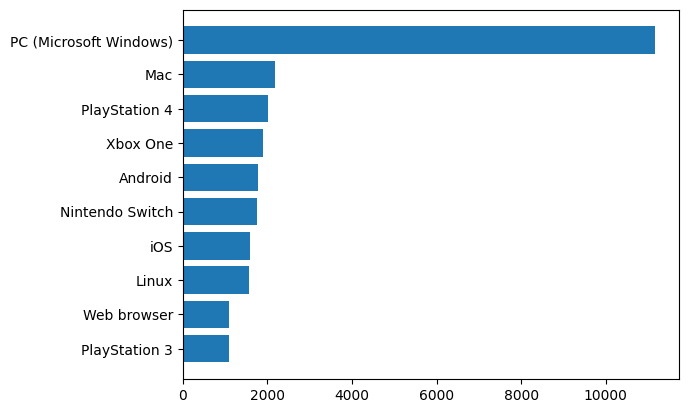

In [178]:
platforms_columns = [column for column in games_df.columns if "platform" in column]

platforms_df = games_df[platforms_columns]

platforms_df.columns = [column[len('platforms_'):] for column in platforms_df.columns]

platforms_amounts = platforms_df.sum().sort_values(ascending = False).head(10).sort_values(ascending=True)

plt.barh(platforms_amounts.index, platforms_amounts.values)

### Distribution of release dates

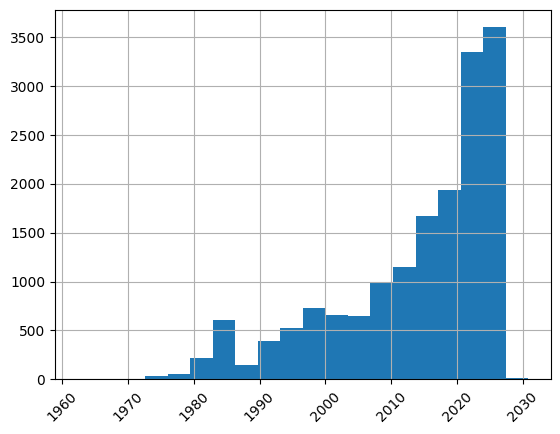

In [179]:
release_dates_without_outliers = games_df[games_df['first_release_date'] > pd.Timestamp('1950')]['first_release_date']

release_dates_without_outliers.hist(bins = 20)
plt.xticks(rotation=45)
plt.show()

# Analyzing data from multiplayer modes endpoint

In [180]:
clean_modes_fp = Path(config['multiplayer_modes_folder'] + config['multiplayer_modes_clean_fp'])

modes_df = pd.read_json(clean_modes_fp, orient='records')

print("Contains " + str(len(modes_df)) + " rows")
modes_df.head()

Contains 24006 rows


,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
0,9953,92273,False,False,False,0,2,False,0,0,Game Boy Color,False
1,1832,7153,True,True,True,2,0,False,0,0,Xbox 360,False
2,7987,57887,False,False,True,2,2,False,0,0,Xbox One,False
3,7,46076,False,False,False,0,30,False,0,0,PC (Microsoft Windows),False
4,10207,31256,False,False,False,0,0,False,0,0,Web browser,False


### Distributions of `offlinecoopmax` and `offlinemax`

In [ ]:
onlinemax_column = modes_df['onlinemax'].sort_values(ascending = False)

onlinemax_column = onlinemax_column[(100 < onlinemax_column) & (onlinemax_column < 1000)]
#offlinemax_column = modes_df[modes_df['offlinemax'] > 0]['offlinemax']

plt.hist(onlinemax_column, alpha=0.5, label='Group A', color='blue')
#plt.hist(offlinemax_column, alpha=0.5, label='Group B', color='orange')
# Formatting
plt.legend(loc='upper right')
plt.title('Overlaid Histograms')
plt.xlim(100, 1000)
plt.show()

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [182]:
outliers = onlinemax_column[onlinemax_column > 100]

In [183]:
max_game = modes_df.loc[outliers.index]
max_game

,id,game,dropin,campaigncoop,offlinecoop,offlinecoopmax,offlinemax,onlinecoop,onlinecoopmax,onlinemax,platform,splitscreen
23965,41130,399755,False,False,False,0,0,False,0,1000,Meta Quest 3,False
23966,41131,399755,False,False,False,0,0,False,0,1000,Meta Quest 2,False
23664,40665,379936,False,False,False,0,0,True,1000,1000,Linux,False
23665,40664,379936,False,False,False,0,0,True,1000,1000,PC (Microsoft Windows),False
23666,40666,379936,False,False,False,0,0,True,1000,1000,Mac,False
...,...,...,...,...,...,...,...,...,...,...,...,...
19275,33842,341687,False,False,False,0,0,True,4,120,PC (Microsoft Windows),False
12776,23204,217618,True,False,False,0,0,True,4,120,iOS,False
9642,18467,194571,True,False,False,0,0,True,120,120,PC (Microsoft Windows),False
12775,23203,217618,False,False,False,0,0,True,4,120,Android,False


In [184]:
max_game.merge(games_df, how = 'left', left_on = 'game', right_on = 'id')[['name', 'platform', 'first_release_date', 'onlinemax']]

,name,platform,first_release_date,onlinemax
0,Vanilla,Meta Quest 3,2026-04-15 00:00:00.000,1000
1,Vanilla,Meta Quest 2,2026-04-15 00:00:00.000,1000
2,Hero,Linux,1677-09-21 00:12:43.145,1000
3,Hero,PC (Microsoft Windows),1677-09-21 00:12:43.145,1000
4,Hero,Mac,1677-09-21 00:12:43.145,1000
...,...,...,...,...
123,Blue Protocol: Star Resonance,PC (Microsoft Windows),2025-07-17 00:00:00.000,120
124,Call of Duty: Warzone Mobile,iOS,2024-03-21 00:00:00.000,120
125,Takepoint.io,PC (Microsoft Windows),2018-03-24 00:00:00.000,120
126,Call of Duty: Warzone Mobile,Android,2024-03-21 00:00:00.000,120
